## Writing a video using OpenCV

Covered:

how to save a video in **avi** and **mp4** formats using OpenCV.

In [1]:
import os
import cv2
import matplotlib.pyplot as plt
from zipfile import ZipFile
from urllib.request import urlretrieve
from IPython.display import YouTubeVideo, display, HTML
from base64 import b64encode
%matplotlib inline

##  <font style="color:black">Download Assets</font>

In [2]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    urlretrieve(url, save_path)

    try:
        with ZipFile(save_path) as z:
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

In [3]:
URL = r"https://www.dropbox.com/s/p8h7ckeo2dn1jtz/opencv_bootcamp_assets_NB6.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), "opencv_bootcamp_assets_NB6.zip")

if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)

## Read Video from Source

In [4]:
source = 'race_car.mp4'
cap = cv2.VideoCapture(source)
if not cap.isOpened():
    print("Error opening video stream or file")

### Read and display one frame

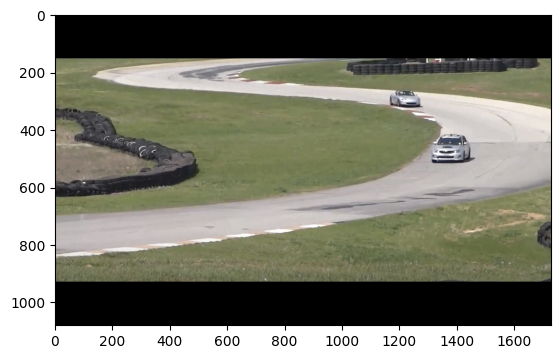

In [5]:
ret, frame = cap.read()
plt.imshow(frame[..., ::-1])

### Display the video file

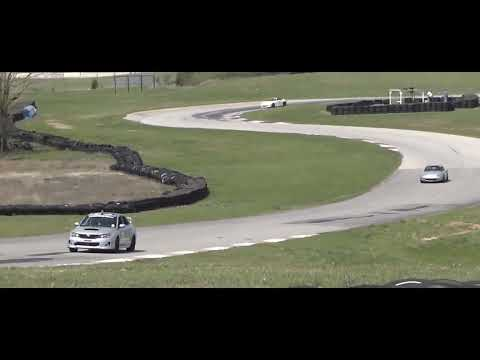

In [6]:
video = YouTubeVideo("RwxVEjv78LQ", width=700, height=438)
display(video)

## Write Video using OpenCV

In [7]:
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))

out_avi = cv2.VideoWriter("race_car_out.avi", cv2.VideoWriter_fourcc("M", "J", "P", "G"), 10, (frame_width, frame_height))

out_mp4 = cv2.VideoWriter("race_car_out.mp4", cv2.VideoWriter_fourcc(*"XVID"), 10, (frame_width, frame_height))

### Read frames and write to file

In [8]:
while cap.isOpened():
    ret, frame = cap.read()

    if ret:
        out_avi.write(frame)
        out_mp4.write(frame)

    else:
        break
cap.release()
out_avi.release()
out_mp4.release()

# To display video on Google Colab

In [9]:
# Installing
!apt-get -qq install ffmpeg

In [11]:
!ffmpeg -y -i "/content/race_car_out.mp4" -c:v libx264 "race_car_out_x264.mp4"  -hide_banner -loglevel error

In [12]:
mp4 = open("/content/race_car_out_x264.mp4", "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""<video width=700 controls><source src="{data_url}" type="video/mp4"></video>""")

Output hidden; open in https://colab.research.google.com to view.